# 9. Perfect Controller Simulation with Weather Data

The weather data was taken from the website `climate.onebuilding.org/WMO_Region_6_Europe` with the file `FRA_AR_Grenoble.Alpes.Isere.AP.074860_TMYx.2011-2025.epw`.

The simulated data is from 2025. We will simulate the system response with 2 scenarios, namely the summer and winter scenarios. Firstly, we simulate the system with no controller, then with a perfect controller for comparison.

For the summer scenario, we simulated from 1st of July to the 31st of July, as this is the hottest month in Grenoble on average.

For the winter scenario, we simulated from 1st of January to the 31st of January, as this is the coldest month in Grenoble on average.

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import dm4bem


## 9.1 Free-Running, No Controller

In free-running mode, no heating or cooling is applied. The indoor temperature evolves freely under outdoor weather, solar irradiance, and internal heat gains only. The large time step ($\Delta t = 1800$ s) is numerically stable because the fast controller dynamics are absent.

### 9.1.1 Summer Simulation — July

<!-- Figure: section4/Jul_free.png — July free-running dynamic response -->

<!-- Figure: section4/Jul_free_data.png — July free-running dynamic response summary -->

Without a controller, the indoor temperature floats freely between $13.2\ °\text{C}$ and $33.5\ °\text{C}$ over the month of July. The indoor temperature (orange) closely tracks the outdoor temperature (blue), with a slight delay due to the thermal mass of the walls. The indoor temperature exceeds $33\ °\text{C}$ on multiple days, well above the standard comfort band of $20$–$26\ °\text{C}$.

The simulation confirms that $q_{HVAC} = 0$ throughout. The total solar irradiance $E_{total}$ shows strong daily peaks reaching up to $\sim 600\ \text{W/m}^2$, which are the primary driver of daytime indoor overheating. No energy is consumed for heating or cooling. This result demonstrates that the building cannot self-regulate its temperature in summer: active cooling would be necessary to maintain comfort.

In [3]:
# Inputs
controller = False
indoor_air_capacity = True
glass_capacity = True

date_start = '2025-07-01 12:00'
date_end = '2025-07-31 12:00'

#date_start = '2025-01-01 12:00'
#date_end = '2025-01-31 12:00'


# Model
# =====
TC = dm4bem.file2TC('TCgen.csv', name='', auto_number=False)

# by default TC['G']['q13'] = 0, i.e. Kp -> 0, no controller (free-floating)
if controller:
    TC['G']['q13'] = 1e4       # Kp, controller gain
if not indoor_air_capacity:
    TC['C']['θ5'] = 0          # indoor air heat capacity
if not glass_capacity:
    TC['C']['θ7'] = 0          # glass (window) heat capacity

TC['f'].replace({
    667.5: 'Q0',
    54.0: 'Q1',
    273.6: 'Q2',
    135.0: 'Q3'
}, inplace=True)


# State-space
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

# Eigenvalues analysis
λ = np.linalg.eig(As)[0]
dt_max = 2 * min(-1. / λ)
dt = dm4bem.round_time(dt_max)
file_weather = 'FRA_AR_Grenoble.Alpes.Isere.AP.074860_TMYx.2011-2025.epw'
[data, meta] = dm4bem.read_epw(file_weather, coerce_year=None)
weather = data[["temp_air", "dir_n_rad", "dif_h_rad"]]
del data

weather.index = weather.index.map(lambda t: t.replace(year=2025))
weather = weather.loc[date_start:date_end]

# Temperature sources
To = weather['temp_air']

Ti_day, Ti_night = 20, 16
Ti = pd.Series(
    [Ti_day if 6 <= hour <= 22 else Ti_night for hour in To.index.hour],
    index=To.index)

# Total solar irradiance (for plotting Etot)
surface_orientation = {'slope': 90, 'azimuth': 0, 'latitude': 45}
albedo = 0.2
rad_surf = dm4bem.sol_rad_tilt_surf(weather, surface_orientation, albedo)
Etot = rad_surf.sum(axis=1)


df = pd.read_csv("TCgen.csv")

# Row corresponding to f vector
f_row = df.loc[df["A"] == "f"].iloc[0]

Q0 = float(f_row["θ0"])   
Q1 = float(f_row["θ4"])   
Q2 = float(f_row["θ7"])   
Q3 = float(f_row["θ8"])   

input_data_set = pd.DataFrame({
    "To":  To,
    "Ti":  Ti,
    "Q0":  Q0,
    "Q1":  Q1,
    "Q2":  Q2,
    "Q3":  Q3,
    "Etot": Etot,
})
# Simulation
# ==========
input_data_set = input_data_set.resample(
    str(dt) + 'S').interpolate(method='linear')

u = dm4bem.inputs_in_time(us, input_data_set)

θ0 = 20
θ_exp = pd.DataFrame(index=u.index)
θ_exp[As.columns] = θ0

I = np.eye(As.shape[0])

for k in range(u.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k + 1]

y = (Cs @ θ_exp.T + Ds @ u.T).T

Kp = TC['G']['q13']
S = 3 * 3
q_HVAC = Kp * (u['q13'] - y['θ5']) / S  # W/m²


C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\3020038146.py:84: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  input_data_set = input_data_set.resample(
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\3020038146.py:96: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20.05764233419889' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\3020038146.py:96: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20.053197597589175' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\3020038

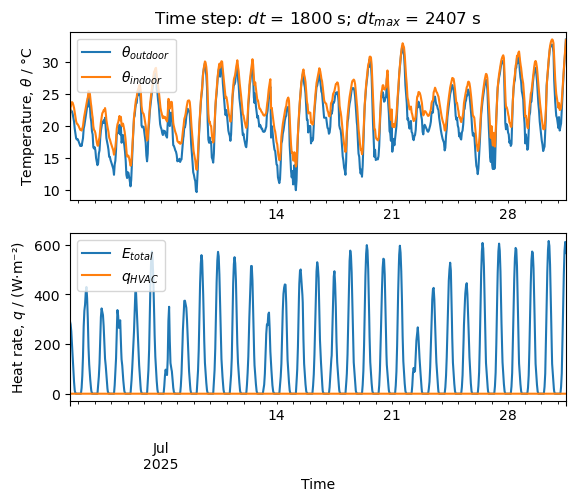

Time step: = 1800 s = 30.0 min
Mean outdoor temperature: 21.1 °C
Min. indoor temperature: 13.2 °C
Max. indoor temperature: 33.5 °C
Max. load: -0.0 W at 2025-07-01 12:00:00+01:00
Energy consumption for heating: 0.0 kWh
Energy consumption for cooling: -0.0 kWh


In [4]:

# Plots
data = pd.DataFrame({'To':     input_data_set['To'],
                     'θi':     y['θ5'],
                     'Etot':   input_data_set['Etot'],
                     'q_HVAC': q_HVAC})

fig, axs = plt.subplots(2, 1)
data[['To', 'θi']].plot(ax=axs[0], xticks=[], ylabel='Temperature, $θ$ / °C')
axs[0].legend(['$θ_{outdoor}$', '$θ_{indoor}$'], loc='upper left')
data[['Etot', 'q_HVAC']].plot(ax=axs[1], ylabel='Heat rate, $q$ / (W·m⁻²)')
axs[1].set(xlabel='Time')
axs[1].legend(['$E_{total}$', '$q_{HVAC}$'], loc='upper left')
axs[0].set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {dt_max:.0f} s')

plt.show()

# Outputs
dm4bem.print_rounded_time("Time step:", dt)
print(f"Mean outdoor temperature: {data['To'].mean():.1f} °C")
print(f"Min. indoor temperature: {data['θi'].min():.1f} °C")
print(f"Max. indoor temperature: {data['θi'].max():.1f} °C")

max_load = data['q_HVAC'].max()
max_load_index = data['q_HVAC'].idxmax()
Q_heat = q_HVAC[q_HVAC > 0].sum() * dt / 3.6e6
Q_cool = q_HVAC[q_HVAC < 0].sum() * dt / 3.6e6

print(f"Max. load: {max_load:.1f} W at {max_load_index}")
print(f"Energy consumption for heating: {Q_heat:.1f} kWh")
print(f"Energy consumption for cooling: {-Q_cool:.1f} kWh")

### 9.1.2 Winter Simulation — January

<!-- Figure: section4/Jan_free.png — January free-running dynamic response -->

<!-- Figure: section4/Jan_free_data.png — January free-running dynamic response summary -->

In January, the free-running indoor temperature ranges from $-2.9\ °\text{C}$ to $20.0\ °\text{C}$. Outdoor temperatures decline steadily through the month, reaching a minimum of approximately $-5.6\ °\text{C}$ around January 19–20. The indoor temperature follows closely, dropping below $0\ °\text{C}$ during the coldest period.

Brief indoor temperature peaks near $20\ °\text{C}$ occur at the start of the month, when solar irradiance provides passive warming during milder days. However, as the month progresses and outdoor temperature falls, solar gains are insufficient to maintain liveable conditions. The $q_{HVAC}$ signal is zero throughout, and no energy is consumed. This confirms that heating is essential in winter: without a controller, the building becomes uninhabitable at sub-zero indoor temperatures.

In [5]:
# Inputs
controller = False
indoor_air_capacity = True
glass_capacity = True

date_start = '2025-01-01 12:00'
date_end = '2025-01-31 12:00'


# Model
# =====
TC = dm4bem.file2TC('TCgen.csv', name='', auto_number=False)

# by default TC['G']['q13'] = 0, i.e. Kp -> 0, no controller (free-floating)
if controller:
    TC['G']['q13'] = 1e4       # Kp, controller gain
if not indoor_air_capacity:
    TC['C']['θ5'] = 0          # indoor air heat capacity
if not glass_capacity:
    TC['C']['θ7'] = 0          # glass (window) heat capacity

TC['f'].replace({
    667.5: 'Q0',
    54.0: 'Q1',
    273.6: 'Q2',
    135.0: 'Q3'
}, inplace=True)


# State-space
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

# Eigenvalues analysis
λ = np.linalg.eig(As)[0]
dt_max = 2 * min(-1. / λ)
dt = dm4bem.round_time(dt_max)
file_weather = 'FRA_AR_Grenoble.Alpes.Isere.AP.074860_TMYx.2011-2025.epw'
[data, meta] = dm4bem.read_epw(file_weather, coerce_year=None)
weather = data[["temp_air", "dir_n_rad", "dif_h_rad"]]
del data

weather.index = weather.index.map(lambda t: t.replace(year=2025))
weather = weather.loc[date_start:date_end]

# Temperature sources
To = weather['temp_air']

Ti_day, Ti_night = 20, 16
Ti = pd.Series(
    [Ti_day if 6 <= hour <= 22 else Ti_night for hour in To.index.hour],
    index=To.index)

# Total solar irradiance (for plotting Etot)
surface_orientation = {'slope': 90, 'azimuth': 0, 'latitude': 45}
albedo = 0.2
rad_surf = dm4bem.sol_rad_tilt_surf(weather, surface_orientation, albedo)
Etot = rad_surf.sum(axis=1)


df = pd.read_csv("TCgen.csv")

# Row corresponding to f vector
f_row = df.loc[df["A"] == "f"].iloc[0]

Q0 = float(f_row["θ0"])   
Q1 = float(f_row["θ4"])   
Q2 = float(f_row["θ7"])   
Q3 = float(f_row["θ8"])   

input_data_set = pd.DataFrame({
    "To":  To,
    "Ti":  Ti,
    "Q0":  Q0,
    "Q1":  Q1,
    "Q2":  Q2,
    "Q3":  Q3,
    "Etot": Etot,
})
# Simulation
# ==========
input_data_set = input_data_set.resample(
    str(dt) + 'S').interpolate(method='linear')

u = dm4bem.inputs_in_time(us, input_data_set)

θ0 = 20
θ_exp = pd.DataFrame(index=u.index)
θ_exp[As.columns] = θ0

I = np.eye(As.shape[0])

for k in range(u.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k + 1]

y = (Cs @ θ_exp.T + Ds @ u.T).T

Kp = TC['G']['q13']
S = 3 * 3
q_HVAC = Kp * (u['q13'] - y['θ5']) / S  # W/m²


C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\4203538981.py:81: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  input_data_set = input_data_set.resample(
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\4203538981.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '19.914437160173527' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\4203538981.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20.053197597589175' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\420353

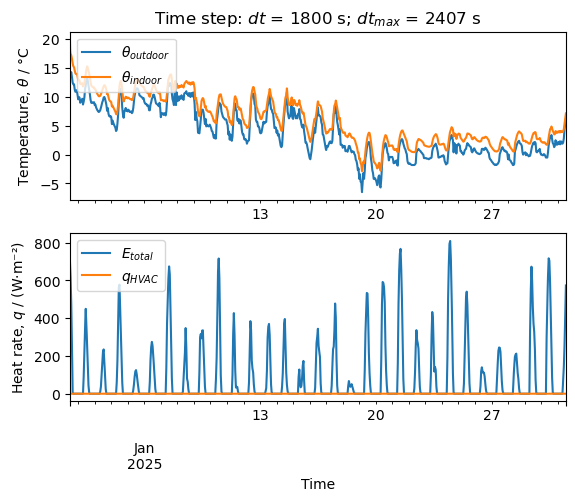

Time step: = 1800 s = 30.0 min
Mean outdoor temperature: 3.9 °C
Min. indoor temperature: -2.9 °C
Max. indoor temperature: 20.0 °C
Max. load: 0.0 W at 2025-01-01 12:00:00+01:00
Energy consumption for heating: 0.0 kWh
Energy consumption for cooling: -0.0 kWh


In [6]:

# Plots
data = pd.DataFrame({'To':     input_data_set['To'],
                     'θi':     y['θ5'],
                     'Etot':   input_data_set['Etot'],
                     'q_HVAC': q_HVAC})

fig, axs = plt.subplots(2, 1)
data[['To', 'θi']].plot(ax=axs[0], xticks=[], ylabel='Temperature, $θ$ / °C')
axs[0].legend(['$θ_{outdoor}$', '$θ_{indoor}$'], loc='upper left')
data[['Etot', 'q_HVAC']].plot(ax=axs[1], ylabel='Heat rate, $q$ / (W·m⁻²)')
axs[1].set(xlabel='Time')
axs[1].legend(['$E_{total}$', '$q_{HVAC}$'], loc='upper left')
axs[0].set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {dt_max:.0f} s')

plt.show()

# Outputs
dm4bem.print_rounded_time("Time step:", dt)
print(f"Mean outdoor temperature: {data['To'].mean():.1f} °C")
print(f"Min. indoor temperature: {data['θi'].min():.1f} °C")
print(f"Max. indoor temperature: {data['θi'].max():.1f} °C")

max_load = data['q_HVAC'].max()
max_load_index = data['q_HVAC'].idxmax()
Q_heat = q_HVAC[q_HVAC > 0].sum() * dt / 3.6e6
Q_cool = q_HVAC[q_HVAC < 0].sum() * dt / 3.6e6

print(f"Max. load: {max_load:.1f} W at {max_load_index}")
print(f"Energy consumption for heating: {Q_heat:.1f} kWh")
print(f"Energy consumption for cooling: {-Q_cool:.1f} kWh")

## 9.2 With Controller

The controller output $q_{HVAC}$ represents the instantaneous heating (positive) or cooling (negative) power applied to the indoor air node. A daily setpoint schedule is applied: $\theta_{sp} = 20\ °\text{C}$ during occupied hours and $\theta_{sp} = 16\ °\text{C}$ at night (setback). The controller gain used was $1\times10^4$. It is suspected that the higher the gain, the lower the time step, hence the lower response time. However, the lower the response time, the higher the power it has to use, and vice versa.

### 9.2.1 Summer Simulation — July

<!-- Figure: section4/Jul_con.png — July controlled dynamic response -->

<!-- Figure: section4/Jul_con_data.png — July controlled dynamic response summary -->

With the controller active, the indoor temperature in July is maintained tightly between $16.0\ °\text{C}$ and $20.1\ °\text{C}$. The indoor temperature (orange) is nearly flat at $20\ °\text{C}$ during occupied hours and drops to the $16\ °\text{C}$ setback at night. Comfort is maintained throughout the month despite outdoor temperatures and solar gains that would otherwise drive the indoor temperature above $33\ °\text{C}$.

The controller output $q_{HVAC}$ takes negative values (cooling) during daytime when solar irradiance is high, reaching approximately $-100\ \text{W/m}^2$. Small positive heating pulses appear in the early morning when the indoor temperature rises from the night setback to the daytime setpoint. Total energy consumption over July is $22.5\ \text{kWh}$ for cooling and $0.8\ \text{kWh}$ for heating, confirming that the summer period is cooling-dominated. The peak load of only $52.7\ \text{W}$ occurs at night on July 14, reflecting good passive performance when solar gains are absent.

In [7]:
# Inputs
controller = True
indoor_air_capacity = True
glass_capacity = True

date_start = '2025-07-01 12:00'
date_end = '2025-07-31 12:00'


# Model
# =====
TC = dm4bem.file2TC('TCgen.csv', name='', auto_number=False)

# by default TC['G']['q13'] = 0, i.e. Kp -> 0, no controller (free-floating)
if controller:
    TC['G']['q13'] = 1e4       # Kp, controller gain
if not indoor_air_capacity:
    TC['C']['θ5'] = 0          # indoor air heat capacity
if not glass_capacity:
    TC['C']['θ7'] = 0          # glass (window) heat capacity

TC['f'].replace({
    667.5: 'Q0',
    54.0: 'Q1',
    273.6: 'Q2',
    135.0: 'Q3'
}, inplace=True)


# State-space
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

# Eigenvalues analysis
λ = np.linalg.eig(As)[0]
dt_max = 2 * min(-1. / λ)
dt = dm4bem.round_time(dt_max)
file_weather = 'FRA_AR_Grenoble.Alpes.Isere.AP.074860_TMYx.2011-2025.epw'
[data, meta] = dm4bem.read_epw(file_weather, coerce_year=None)
weather = data[["temp_air", "dir_n_rad", "dif_h_rad"]]
del data

weather.index = weather.index.map(lambda t: t.replace(year=2025))
weather = weather.loc[date_start:date_end]

# Temperature sources
To = weather['temp_air']

Ti_day, Ti_night = 20, 16
Ti = pd.Series(
    [Ti_day if 6 <= hour <= 22 else Ti_night for hour in To.index.hour],
    index=To.index)

# Total solar irradiance (for plotting Etot)
surface_orientation = {'slope': 90, 'azimuth': 0, 'latitude': 45}
albedo = 0.2
rad_surf = dm4bem.sol_rad_tilt_surf(weather, surface_orientation, albedo)
Etot = rad_surf.sum(axis=1)


df = pd.read_csv("TCgen.csv")

# Row corresponding to f vector
f_row = df.loc[df["A"] == "f"].iloc[0]

Q0 = float(f_row["θ0"])   
Q1 = float(f_row["θ4"])   
Q2 = float(f_row["θ7"])   
Q3 = float(f_row["θ8"])   

input_data_set = pd.DataFrame({
    "To":  To,
    "Ti":  Ti,
    "Q0":  Q0,
    "Q1":  Q1,
    "Q2":  Q2,
    "Q3":  Q3,
    "Etot": Etot,
})
# Simulation
# ==========
input_data_set = input_data_set.resample(
    str(dt) + 'S').interpolate(method='linear')

u = dm4bem.inputs_in_time(us, input_data_set)

θ0 = 20
θ_exp = pd.DataFrame(index=u.index)
θ_exp[As.columns] = θ0

I = np.eye(As.shape[0])

for k in range(u.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k + 1]

y = (Cs @ θ_exp.T + Ds @ u.T).T

Kp = TC['G']['q13']
S = 3 * 3
q_HVAC = Kp * (u['q13'] - y['θ5']) / S  # W/m²


C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\2515097083.py:81: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  input_data_set = input_data_set.resample(
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\2515097083.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20.00058109343851' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\2515097083.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20.000591084417657' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\2515097

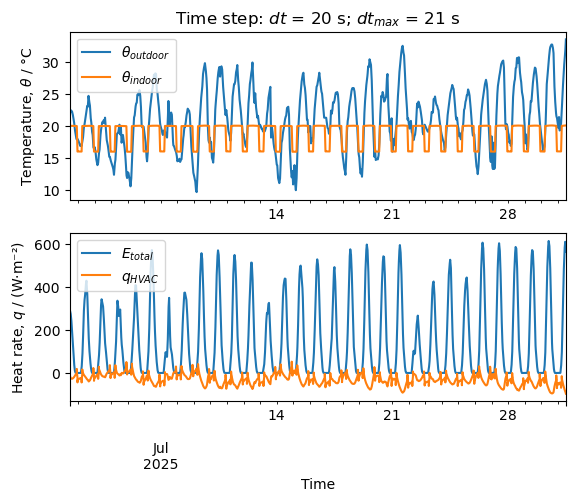

Time step: = 20 s
Mean outdoor temperature: 21.1 °C
Min. indoor temperature: 16.0 °C
Max. indoor temperature: 20.1 °C
Max. load: 52.7 W at 2025-07-14 22:00:20+01:00
Energy consumption for heating: 0.8 kWh
Energy consumption for cooling: 22.5 kWh


In [8]:

# Plots
data = pd.DataFrame({'To':     input_data_set['To'],
                     'θi':     y['θ5'],
                     'Etot':   input_data_set['Etot'],
                     'q_HVAC': q_HVAC})

fig, axs = plt.subplots(2, 1)
data[['To', 'θi']].plot(ax=axs[0], xticks=[], ylabel='Temperature, $θ$ / °C')
axs[0].legend(['$θ_{outdoor}$', '$θ_{indoor}$'], loc='upper left')
data[['Etot', 'q_HVAC']].plot(ax=axs[1], ylabel='Heat rate, $q$ / (W·m⁻²)')
axs[1].set(xlabel='Time')
axs[1].legend(['$E_{total}$', '$q_{HVAC}$'], loc='upper left')
axs[0].set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {dt_max:.0f} s')

plt.show()

# Outputs
dm4bem.print_rounded_time("Time step:", dt)
print(f"Mean outdoor temperature: {data['To'].mean():.1f} °C")
print(f"Min. indoor temperature: {data['θi'].min():.1f} °C")
print(f"Max. indoor temperature: {data['θi'].max():.1f} °C")

max_load = data['q_HVAC'].max()
max_load_index = data['q_HVAC'].idxmax()
Q_heat = q_HVAC[q_HVAC > 0].sum() * dt / 3.6e6
Q_cool = q_HVAC[q_HVAC < 0].sum() * dt / 3.6e6

print(f"Max. load: {max_load:.1f} W at {max_load_index}")
print(f"Energy consumption for heating: {Q_heat:.1f} kWh")
print(f"Energy consumption for cooling: {-Q_cool:.1f} kWh")

### 9.2.2 Winter Simulation — January

<!-- Figure: section4/Jan_con.png — January controlled dynamic response -->

<!-- Figure: section4/Jan_con_data.png — January controlled dynamic response summary -->

In January, the controller maintains the indoor temperature between $15.9\ °\text{C}$ and $20.0\ °\text{C}$. The upper plot shows a clear day-night pattern: the indoor temperature (orange) alternates between the $20\ °\text{C}$ occupied setpoint and the $16\ °\text{C}$ night setback, regardless of how cold it is outside. Outdoor temperatures fall as low as $-5.6\ °\text{C}$, but the indoor environment remains comfortable at all times.

The controller output $q_{HVAC}$ is entirely positive (heating only) throughout January. The heating load increases noticeably during the coldest period around January 19–21, where higher sustained heating power is required to compensate for the large indoor-outdoor temperature difference. The total heating energy for January is $64.3\ \text{kWh}$, with a peak load of $171.9\ \text{W}$ occurring at night on January 19 — the coldest point of the simulation. No cooling is required ($0.0\ \text{kWh}$), confirming that January is heating-dominated. The winter heating demand ($64.3\ \text{kWh}$) is approximately 3 times greater than the summer cooling demand ($22.5\ \text{kWh}$), highlighting the severity of thermal losses through the building envelope when outdoor temperatures are well below the setpoint.

In [9]:
# Inputs
controller = True
indoor_air_capacity = True
glass_capacity = True

date_start = '2025-01-01 12:00'
date_end = '2025-01-31 12:00'


# Model
# =====
TC = dm4bem.file2TC('TCgen.csv', name='', auto_number=False)

# by default TC['G']['q13'] = 0, i.e. Kp -> 0, no controller (free-floating)
if controller:
    TC['G']['q13'] = 1e4       # Kp, controller gain
if not indoor_air_capacity:
    TC['C']['θ5'] = 0          # indoor air heat capacity
if not glass_capacity:
    TC['C']['θ7'] = 0          # glass (window) heat capacity

TC['f'].replace({
    667.5: 'Q0',
    54.0: 'Q1',
    273.6: 'Q2',
    135.0: 'Q3'
}, inplace=True)


# State-space
[As, Bs, Cs, Ds, us] = dm4bem.tc2ss(TC)

# Eigenvalues analysis
λ = np.linalg.eig(As)[0]
dt_max = 2 * min(-1. / λ)
dt = dm4bem.round_time(dt_max)
file_weather = 'FRA_AR_Grenoble.Alpes.Isere.AP.074860_TMYx.2011-2025.epw'
[data, meta] = dm4bem.read_epw(file_weather, coerce_year=None)
weather = data[["temp_air", "dir_n_rad", "dif_h_rad"]]
del data

weather.index = weather.index.map(lambda t: t.replace(year=2025))
weather = weather.loc[date_start:date_end]

# Temperature sources
To = weather['temp_air']

Ti_day, Ti_night = 20, 16
Ti = pd.Series(
    [Ti_day if 6 <= hour <= 22 else Ti_night for hour in To.index.hour],
    index=To.index)

# Total solar irradiance (for plotting Etot)
surface_orientation = {'slope': 90, 'azimuth': 0, 'latitude': 45}
albedo = 0.2
rad_surf = dm4bem.sol_rad_tilt_surf(weather, surface_orientation, albedo)
Etot = rad_surf.sum(axis=1)


df = pd.read_csv("TCgen.csv")

# Row corresponding to f vector
f_row = df.loc[df["A"] == "f"].iloc[0]

Q0 = float(f_row["θ0"])   
Q1 = float(f_row["θ4"])   
Q2 = float(f_row["θ7"])   
Q3 = float(f_row["θ8"])   

input_data_set = pd.DataFrame({
    "To":  To,
    "Ti":  Ti,
    "Q0":  Q0,
    "Q1":  Q1,
    "Q2":  Q2,
    "Q3":  Q3,
    "Etot": Etot,
})
# Simulation
# ==========
input_data_set = input_data_set.resample(
    str(dt) + 'S').interpolate(method='linear')

u = dm4bem.inputs_in_time(us, input_data_set)

θ0 = 20
θ_exp = pd.DataFrame(index=u.index)
θ_exp[As.columns] = θ0

I = np.eye(As.shape[0])

for k in range(u.shape[0] - 1):
    θ_exp.iloc[k + 1] = (I + dt * As)\
        @ θ_exp.iloc[k] + dt * Bs @ u.iloc[k + 1]

y = (Cs @ θ_exp.T + Ds @ u.T).T

Kp = TC['G']['q13']
S = 3 * 3
q_HVAC = Kp * (u['q13'] - y['θ5']) / S  # W/m²


C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\1196281508.py:81: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  input_data_set = input_data_set.resample(
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\1196281508.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '19.99909878256427' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\1196281508.py:93: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20.000591084417657' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  θ_exp.iloc[k + 1] = (I + dt * As)\
C:\Users\Thinh Lam-The Tran\AppData\Local\Temp\ipykernel_41504\1196281

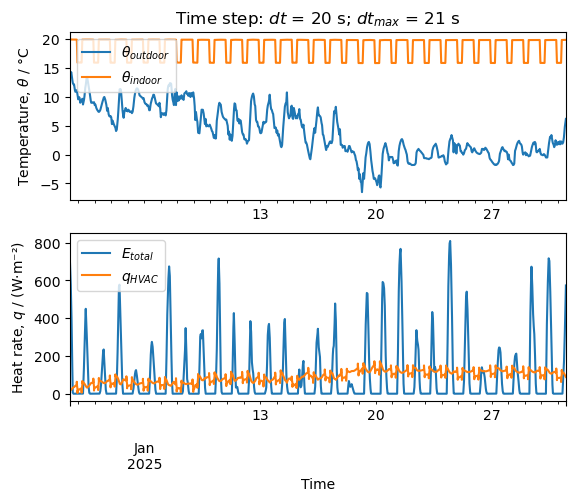

Time step: = 20 s
Mean outdoor temperature: 3.9 °C
Min. indoor temperature: 15.9 °C
Max. indoor temperature: 20.0 °C
Max. load: 171.9 W at 2025-01-19 22:00:20+01:00
Energy consumption for heating: 64.3 kWh
Energy consumption for cooling: -0.0 kWh


In [10]:

# Plots
data = pd.DataFrame({'To':     input_data_set['To'],
                     'θi':     y['θ5'],
                     'Etot':   input_data_set['Etot'],
                     'q_HVAC': q_HVAC})

fig, axs = plt.subplots(2, 1)
data[['To', 'θi']].plot(ax=axs[0], xticks=[], ylabel='Temperature, $θ$ / °C')
axs[0].legend(['$θ_{outdoor}$', '$θ_{indoor}$'], loc='upper left')
data[['Etot', 'q_HVAC']].plot(ax=axs[1], ylabel='Heat rate, $q$ / (W·m⁻²)')
axs[1].set(xlabel='Time')
axs[1].legend(['$E_{total}$', '$q_{HVAC}$'], loc='upper left')
axs[0].set_title(f'Time step: $dt$ = {dt:.0f} s; $dt_{{max}}$ = {dt_max:.0f} s')

plt.show()

# Outputs
dm4bem.print_rounded_time("Time step:", dt)
print(f"Mean outdoor temperature: {data['To'].mean():.1f} °C")
print(f"Min. indoor temperature: {data['θi'].min():.1f} °C")
print(f"Max. indoor temperature: {data['θi'].max():.1f} °C")

max_load = data['q_HVAC'].max()
max_load_index = data['q_HVAC'].idxmax()
Q_heat = q_HVAC[q_HVAC > 0].sum() * dt / 3.6e6
Q_cool = q_HVAC[q_HVAC < 0].sum() * dt / 3.6e6

print(f"Max. load: {max_load:.1f} W at {max_load_index}")
print(f"Energy consumption for heating: {Q_heat:.1f} kWh")
print(f"Energy consumption for cooling: {-Q_cool:.1f} kWh")